In [1]:
import earthaccess
import xarray as xr

In [ ]:
product = "PACE_OCI_L3M_SFREFL_NRT"
date_ini, date_end= '2024-03-22', '2024-04-09'
# Level 3 data
lon_min, lon_max = -98, -78
lat_min, lat_max = 18, 30.5
results = earthaccess.search_data(
    short_name = product,
    temporal = (date_ini, date_end),
    bounding_box = (lon_min, lat_min, lon_max, lat_max)
)
len(results)

In [ ]:
print(results[0]['meta']['native-id'])
print(results[0]['umm']['TemporalExtent'])


In [9]:
for result in results[0:5]:
    print(f'{result['meta']['native-id']}')
    print(f'{result['meta']['native-id'].split('.')[1]}')
    print(f'{result['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime']}')
    print(f'{result['umm']['TemporalExtent']['RangeDateTime']['EndingDateTime']}\n')

PACE_OCI_L3M_SFREFL_PACE_OCI.20240301_20240331.L3m.MO.SFREFL.V3_1.rhos.0p1deg.nc_3.1
20240301_20240331
2024-03-05T00:00:00Z
2024-03-31T23:59:59Z

PACE_OCI_L3M_SFREFL_PACE_OCI.20240301_20240331.L3m.MO.SFREFL.V3_1.rhos.4km.nc_3.1
20240301_20240331
2024-03-05T00:00:00Z
2024-03-31T23:59:59Z

PACE_OCI_L3M_SFREFL_PACE_OCI.20240301_20240331.L3m.MO.SFREFL.V3_1.rhos.2km.nc_3.1
20240301_20240331
2024-03-05T00:00:00Z
2024-03-31T23:59:59Z

PACE_OCI_L3M_SFREFL_PACE_OCI.20240305_20240405.L3m.R32.SFREFL.V3_1.rhos.0p1deg.nc_3.1
20240305_20240405
2024-03-05T00:00:00Z
2024-04-05T23:59:59Z

PACE_OCI_L3M_SFREFL_PACE_OCI.20240305_20240405.L3m.R32.SFREFL.V3_1.rhos.4km.nc_3.1
20240305_20240405
2024-03-05T00:00:00Z
2024-04-05T23:59:59Z



In [12]:
product = "PACE_OCI_L3M_SFREFL"
date_ini, date_end= '2024-03-22', '2024-04-09'
# Level 3 data
results = earthaccess.search_data(
    short_name = product,
    temporal = (date_ini, date_end),
    granule_name="*DAY*0p1deg*"
)
len(results)

17

In [13]:
for result in results[0:5]:
    print(f'{result['meta']['native-id']}')
    print(f'{result['meta']['native-id'].split('.')[1]}')
    print(f'{result['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime']}')
    print(f'{result['umm']['TemporalExtent']['RangeDateTime']['EndingDateTime']}\n')

PACE_OCI_L3M_SFREFL_PACE_OCI.20240322.L3m.DAY.SFREFL.V3_1.rhos.0p1deg.nc_3.1
20240322
2024-03-22T00:00:00Z
2024-03-22T23:59:59Z

PACE_OCI_L3M_SFREFL_PACE_OCI.20240323.L3m.DAY.SFREFL.V3_1.rhos.0p1deg.nc_3.1
20240323
2024-03-23T00:00:00Z
2024-03-23T23:59:59Z

PACE_OCI_L3M_SFREFL_PACE_OCI.20240324.L3m.DAY.SFREFL.V3_1.rhos.0p1deg.nc_3.1
20240324
2024-03-24T00:00:00Z
2024-03-24T23:59:59Z

PACE_OCI_L3M_SFREFL_PACE_OCI.20240325.L3m.DAY.SFREFL.V3_1.rhos.0p1deg.nc_3.1
20240325
2024-03-25T00:00:00Z
2024-03-25T23:59:59Z

PACE_OCI_L3M_SFREFL_PACE_OCI.20240328.L3m.DAY.SFREFL.V3_1.rhos.0p1deg.nc_3.1
20240328
2024-03-28T00:00:00Z
2024-03-28T23:59:59Z



In [14]:
fileset = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/17 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/17 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/17 [00:00<?, ?it/s]

In [23]:
fileset[0].full_name.split('.')[1]

'20240322'

In [45]:
import xarray as xr
import pandas as pd
import re
lat_start, lon_start = 19.2, -92.5
lat_end, lon_end = 19.3, -91.5

# Límites para el Golfo de México / Caribe
lon_min, lon_max = -92.25, -91.75
lat_min, lat_max = 19, 19.5

def extract_time_from_filename(fname):
    # Ajustado para buscar .YYYYMMDD.
    # El patrón busca un punto, seguido de 8 dígitos, seguido de otro punto
    match = re.search(r'\.(\d{8})\.', str(fname))
    if not match:
        raise ValueError(f"No se pudo extraer la fecha del archivo: {fname}")
    return pd.to_datetime(match.group(1), format="%Y%m%d")

# --------------------------------------------------
# Carga optimizada
# --------------------------------------------------
datasets = []

for f in fileset:
    # Usamos f.name si f es un objeto Path, o f si es un string
    fname_str = f.name if hasattr(f, 'name') else str(f)
    fecha = extract_time_from_filename(fname_str)
    
    # Abrimos de forma lazy
    temp_ds = xr.open_dataset(f, chunks={})
    
    # Asignamos la dimensión de tiempo y expandimos
    temp_ds = temp_ds.assign_coords(time=fecha).expand_dims("time")
    
    # Aplicamos el recorte espacial de inmediato (subsetting temprano)
    # Nota: slice(lat_max, lat_min) porque en NetCDF de NASA 'lat' suele ir de 90 a -90
    temp_ds = temp_ds.sel(
        lon=slice(lon_min, lon_max),
        lat=slice(lat_max, lat_min)
    )
    
    datasets.append(temp_ds)

# --------------------------------------------------
# Concatenación final
# --------------------------------------------------
ds = xr.concat(datasets, dim="time")


In [46]:
ds

<xarray.Dataset> Size: 263kB
Dimensions:     (time: 17, lat: 5, lon: 6, wavelength: 122, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * time        (time) datetime64[ns] 136B 2024-03-22 2024-03-23 ... 2024-04-09
  * lat         (lat) float32 20B 19.45 19.35 19.25 19.15 19.05
  * lon         (lon) float32 24B -92.25 -92.15 -92.05 -91.95 -91.85 -91.75
  * wavelength  (wavelength) float64 976B 346.0 351.0 ... 2.131e+03 2.258e+03
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    rhos        (time, lat, lon, wavelength) float32 249kB dask.array<chunksize=(1, 5, 6, 8), meta=np.ndarray>
    palette     (time, rgb, eightbitcolor) uint8 13kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/62)
    product_name:                      PACE_OCI.20240322.L3m.DAY.SFREFL.V3_1....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    cdm_data_type:                     grid
    identifier_product_doi_authority:  http://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/SFREFL/3.1
    data_bins:                         2245933
    data_minimum:                      -0.04924447
    data_maximum:                      1.49999

In [48]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup coordinates for the transect
lat_start, lon_start = 19.2, -91.5
lat_end, lon_end = 19.3, -92.4
n_samples = 10

# 2. Generate coordinate arrays
target_lats = xr.DataArray(np.linspace(lat_start, lat_end, n_samples), dims='transect_idx')
target_lons = xr.DataArray(np.linspace(lon_start, lon_end, n_samples), dims='transect_idx')

# 3. Extract data using Nearest Neighbor sampling
transect_raw = ds.rhos.sel(lat=target_lats, lon=target_lons, method='nearest')

# 4. Visualization
wave_axis = ds.wavelength.values

for t_idx in range(len(transect_raw.time)):
    plt.figure(figsize=(12, 7))
    
    # Get data for current time step
    current_step = transect_raw.isel(time=t_idx)
    timestamp = np.datetime_as_string(current_step.time.values, unit='D')
    
    # Define color palette based on space progression
    colors = plt.cm.plasma(np.linspace(0, 1, n_samples))
    
    for p_idx in range(n_samples):
        # Extracting the raw spectral vector for one pixel
        pixel_spectrum = current_step.isel(transect_idx=p_idx)
        
        # Plotting the raw data (only if not NaN)
        if not np.all(np.isnan(pixel_spectrum)):
            plt.plot(wave_axis, pixel_spectrum, color=colors[p_idx], alpha=0.8, lw=0.8)

    # Statistical reference (Mean of the sampled pixels)
    #plt.plot(wave_axis, current_step.mean(dim='transect_idx'), 
    #         color='black', lw=2.5, label='Spatial Average (Raw Pixels)')

    # Chart formatting
    plt.title(f"PACE/OCI Raw Spectral Transect \nDate: {timestamp}", fontsize=14)
    plt.xlabel("Wavelength (nm)", fontsize=12)
    plt.ylabel("Surface Reflectance (rhos)", fontsize=12)
    
    # Setting limits based on metadata
    plt.ylim(0, 0.18) # Focused on ocean reflectance typical ranges
    #plt.xlim(340, 900) #
    
    plt.grid(True, which='both', ls=':', alpha=0.6)
    plt.legend()
    
    # Colorbar to indicate geographical direction
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=0, vmax=n_samples))
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('Geographical progression (Start Point -> End Point)')
    
    plt.tight_layout()
    plt.show()

KeyboardInterrupt: 

<Figure size 1200x700 with 0 Axes>

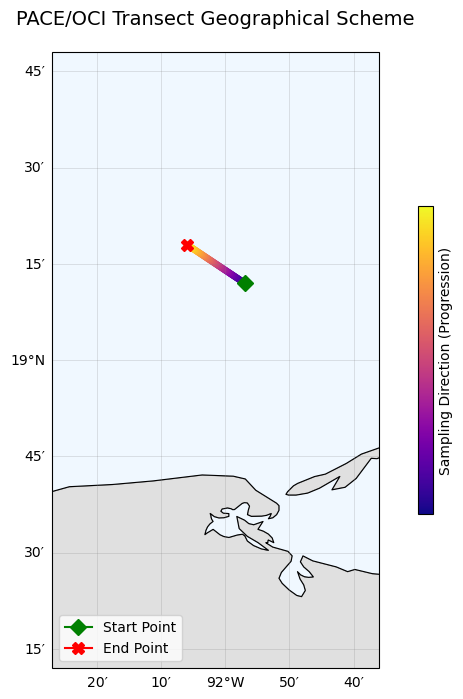

In [35]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 1. Define transect coordinates
#Latitud: 19.3991° N

#Longitud: −92.0532° O

lat_start, lon_start = 19.2, -91.95
lat_end, lon_end = 19.3, -92.1

# 2. Setup the map projection
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Add geographic layers for context (High resolution)
ax.add_feature(cfeature.LAND, facecolor='#e0e0e0', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='#f0f8ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)

# 4. Draw the transect path
# We create intermediate points to show the direction with a color gradient
n_points = 100
lons = np.linspace(lon_start, lon_end, n_points)
lats = np.linspace(lat_start, lat_end, n_points)

# Plotting the line
ax.plot(lons, lats, color='black', linestyle='--', linewidth=1, 
        transform=ccrs.PlateCarree(), zorder=1)

# Scatter plot with colormap to show direction (Start to End)
path = ax.scatter(lons, lats, c=np.arange(n_points), cmap='plasma', 
                   s=15, transform=ccrs.PlateCarree(), zorder=2)

# 5. Mark and label the Start and End points
ax.plot(lon_start, lat_start, marker='D', color='green', markersize=8, 
        transform=ccrs.PlateCarree(), label='Start Point', zorder=3)
ax.plot(lon_end, lat_end, marker='X', color='red', markersize=9, 
        transform=ccrs.PlateCarree(), label='End Point', zorder=3)

# 6. Final Layout & Labels
plt.title("PACE/OCI Transect Geographical Scheme", fontsize=14, pad=20)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                  linewidth=0.5, color='gray', alpha=0.3)
gl.top_labels = False
gl.right_labels = False

# Add colorbar to explain the direction
cbar = plt.colorbar(path, ax=ax, orientation='vertical', shrink=0.5, pad=0.05)
cbar.set_label('Sampling Direction (Progression)')
cbar.set_ticks([]) # Remove numbers for a cleaner scheme

# Set map extent (Zoom into the transect area with some padding)
ax.set_extent([lon_start-.5, lon_end+.5, lat_start-1, lat_end+.5])

plt.legend(loc='lower left')
plt.show()

In [11]:
ds.time

<xarray.DataArray 'time' (time: 6)> Size: 48B
array(['2024-03-05T00:00:00.000000000', '2024-02-26T00:00:00.000000000',
       '2024-03-13T00:00:00.000000000', '2024-03-21T00:00:00.000000000',
       '2024-03-29T00:00:00.000000000', '2024-04-06T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 48B 2024-03-05 2024-02-26 ... 2024-04-06